# SIT215 Assignment 1 : Problem Solving
## Aachen Wheelchair Navigation

##

## Task 1 & 2 -> Environment and Basic A*

#### The Aachen environment is represented as a graph of 21 nodes and 32 path segments. Task 2 uses physical distance as the edge cost and Haversine distance as the heuristic value for a*

In [1]:
import math
import heapq
import time
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
coordinates = {
    "N1": (50.77442210, 6.08382150),
    "N2": (50.77601180, 6.08336740),
    "N3": (50.77408300, 6.08742570),
    "N4": (50.77515270, 6.08264400),
    "N5": (50.77549340, 6.08354790),
    "N6": (50.77649160, 6.08382680),
    "N7": (50.77519490, 6.08439060),
    "N8": (50.77578130, 6.08491480),
    "N9": (50.77468120, 6.08563640),
    "N10": (50.77636540, 6.08326870),
    "N11": (50.77369650, 6.08389040),
    "N12": (50.77326930, 6.08669810),
    "N13": (50.77223030, 6.08788510),
    "N14": (50.77331680, 6.08788540),
    "N15": (50.77209340, 6.08491950),
    "N16": (50.77536940, 6.08401690),
    "N17": (50.77465940, 6.08174100),
    "N18": (50.77470010, 6.08464560),
    "N19": (50.77632370, 6.08435900),
    "N20": (50.77654230, 6.08534830),
    "N21": (50.77565080, 6.08461950)
}

In [3]:
def haversine_distance(node1, node2):
    lat1, lon1 = coordinates[node1]
    lat2, lon2 = coordinates[node2]

    R = 6371000
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

In [4]:
graph = {
    "N1":  {"N11": 80.83, "N18": 65.68, "N17": 148.65},
    "N2":  {"N10": 39.93, "N19": 77.87, "N5": 59.02},
    "N3":  {"N12": 103.94, "N9": 142.32, "N11": 252.28},
    "N4":  {"N5": 73.99, "N18": 149.47, "N17": 83.91},
    "N5":  {"N16": 35.74, "N4": 73.99, "N2": 59.02},
    "N6":  {"N10": 41.68, "N19": 41.82, "N20": 107.13},
    "N7":  {"N16": 32.66, "N18": 57.87, "N21": 53.19},
    "N8":  {"N20": 89.94, "N21": 25.33, "N19": 71.87, "N9": 132.43},
    "N9":  {"N3": 142.32, "N8": 132.43, "N18": 69.70},
    "N10": {"N6": 41.68, "N2": 39.93},
    "N11": {"N15": 192.39, "N1": 80.83, "N18": 123.59, "N3": 252.28},
    "N12": {"N13": 142.53, "N15": 180.94, "N14": 83.66, "N3": 103.94},
    "N13": {"N15": 209.10, "N12": 142.53, "N14": 120.81},
    "N14": {"N12": 83.66, "N13": 120.81},
    "N15": {"N13": 209.10, "N12": 180.94, "N11": 192.39},
    "N16": {"N5": 35.74, "N7": 32.66},
    "N17": {"N4": 83.91, "N1": 148.65},
    "N18": {"N1": 65.68, "N11": 123.59, "N7": 57.87, "N4": 149.47, "N9": 69.70},
    "N19": {"N6": 41.82, "N2": 77.87, "N21": 77.03, "N8": 71.87},
    "N20": {"N8": 89.94, "N6": 107.13},
    "N21": {"N8": 25.33, "N19": 77.03, "N7": 53.19}
}

start_node = "N20"
goal_node = "N13"

In [5]:
def a_star_distance(graph, start, goal):
    open_set = [(haversine_distance(start, goal), start)]
    came_from = {}
    g_score = {node: float("inf") for node in graph}
    g_score[start] = 0
    nodes_expanded = 0

    while open_set:
        _, current = heapq.heappop(open_set)
        nodes_expanded += 1

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path, g_score[goal], nodes_expanded

        for neighbour, edge_cost in graph[current].items():
            tentative_g = g_score[current] + edge_cost

            if tentative_g < g_score[neighbour]:
                came_from[neighbour] = current
                g_score[neighbour] = tentative_g
                f = tentative_g + haversine_distance(neighbour, goal)
                heapq.heappush(open_set, (f, neighbour))

    return None, float("inf"), nodes_expanded

In [6]:
test_cases = [
    ("N20", "N13"),
    ("N1", "N8"),
    ("N15", "N6"),
    ("N17", "N20"),
    ("N4", "N21")
]

distance_results = []

for start, goal in test_cases:
    path, cost, expanded = a_star_distance(graph, start, goal)

    distance_results.append({
        "Start": start,
        "Goal": goal,
        "Path": " → ".join(path),
        "Distance (m)": round(cost, 2),
        "Nodes Expanded": expanded
    })

distance_results_df = pd.DataFrame(distance_results)
distance_results_df

,Start,Goal,Path,Distance (m),Nodes Expanded
0,N20,N13,N20 → N8 → N9 → N3 → N12 → N13,611.16,20
1,N1,N8,N1 → N18 → N7 → N21 → N8,202.07,7
2,N15,N6,N15 → N11 → N18 → N7 → N21 → N19 → N6,545.89,16
3,N17,N20,N17 → N4 → N5 → N16 → N7 → N21 → N8 → N20,394.76,15
4,N4,N21,N4 → N5 → N16 → N7 → N21,195.58,6


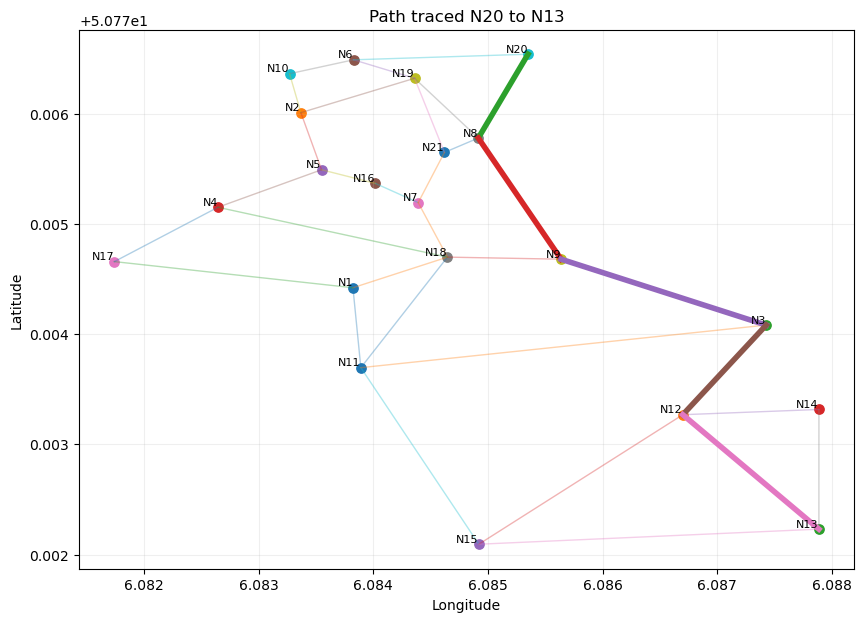

In [7]:
plt.figure(figsize=(10, 7))

for node, neighbours in graph.items():
    for neighbour in neighbours:
        if node < neighbour:
            lat1, lon1 = coordinates[node]
            lat2, lon2 = coordinates[neighbour]
            plt.plot([lon1, lon2], [lat1, lat2], linewidth=1, alpha=0.35)

for node, (lat, lon) in coordinates.items():
    plt.scatter(lon, lat, s=45)
    plt.text(lon, lat, node, fontsize=8, ha="right", va="bottom")

path, _, _ = a_star_distance(graph, start_node, goal_node)

for i in range(len(path) - 1):
    lat1, lon1 = coordinates[path[i]]
    lat2, lon2 = coordinates[path[i + 1]]
    plt.plot([lon1, lon2], [lat1, lat2], linewidth=4)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Path traced N20 to N13")
plt.grid(alpha=0.2)
plt.show()

## 

## Task 3 -> Environmental Constraints and Effort-Based A*

#### Each path segment is assigned an effort constraint value:

#### The effort cost is:
**E = L × (1 + U + D + R + K + O)**

#### where L is the physical distance in metres and the other values in variables range from 0 to 1

#### The enhanced heuristic estimates the remaining effort from the current node to the goal using a distance-based reference path.

In [8]:
environment = {
    ("N15", "N13"): (0.50, 0.00, 0.50, 0.50, 0.25),
    ("N12", "N13"): (0.00, 0.50, 0.25, 0.25, 0.00),
    ("N15", "N12"): (0.25, 0.00, 0.50, 0.25, 0.25),
    ("N12", "N14"): (0.00, 0.25, 0.25, 0.00, 0.00),
    ("N13", "N14"): (0.00, 0.25, 0.50, 0.25, 0.25),
    ("N15", "N11"): (0.50, 0.00, 0.50, 0.50, 0.50),
    ("N11", "N1"):  (0.25, 0.00, 0.25, 0.25, 0.00),
    ("N12", "N3"):  (0.25, 0.00, 0.25, 0.25, 0.25),
    ("N3", "N9"):   (0.00, 0.25, 0.25, 0.50, 0.25),
    ("N1", "N18"):  (0.00, 0.25, 0.25, 0.00, 0.00),
    ("N11", "N18"): (0.25, 0.00, 0.50, 0.25, 0.25),
    ("N5", "N16"):  (0.00, 0.00, 0.00, 0.00, 0.00),
    ("N10", "N6"):  (0.00, 0.25, 0.25, 0.25, 0.00),
    ("N10", "N2"):  (0.25, 0.00, 0.25, 0.25, 0.00),
    ("N6", "N19"):  (0.00, 0.25, 0.50, 0.25, 0.25),
    ("N20", "N8"):  (0.50, 0.00, 0.25, 0.25, 0.25),
    ("N21", "N8"):  (0.00, 0.00, 0.00, 0.00, 0.00),
    ("N19", "N2"):  (0.25, 0.00, 0.25, 0.50, 0.25),
    ("N21", "N19"): (0.00, 0.25, 0.50, 0.25, 0.50),
    ("N16", "N7"):  (0.00, 0.00, 0.25, 0.00, 0.00),
    ("N18", "N7"):  (0.25, 0.00, 0.25, 0.25, 0.00),
    ("N4", "N5"):   (0.00, 0.25, 0.00, 0.00, 0.00),
    ("N4", "N18"):  (0.50, 0.00, 0.50, 0.50, 0.25),
    ("N17", "N4"):  (0.25, 0.00, 0.25, 0.25, 0.25),
    ("N19", "N8"):  (0.00, 0.25, 0.25, 0.25, 0.00),
    ("N9", "N8"):   (0.25, 0.00, 0.50, 0.50, 0.25),
    ("N17", "N1"):  (0.50, 0.00, 0.50, 0.25, 0.50),
    ("N18", "N9"):  (0.00, 0.25, 0.25, 0.25, 0.00),
    ("N5", "N2"):   (0.25, 0.00, 0.00, 0.00, 0.00),
    ("N11", "N3"):  (0.50, 0.00, 0.75, 0.50, 0.50),
    ("N7", "N21"):  (0.00, 0.25, 0.25, 0.25, 0.00),
    ("N6", "N20"):  (0.50, 0.00, 0.50, 0.50, 0.25)
}

for (node1, node2), values in list(environment.items()):
    environment[(node2, node1)] = values

In [9]:
def calculate_effort(L, U, D, R, K, O):
    return L * (1 + U + D + R + K + O)

effort_graph = {node: {} for node in graph}

for node1 in graph:
    for node2, distance in graph[node1].items():
        U, D, R, K, O = environment[(node1, node2)]
        effort_graph[node1][node2] = calculate_effort(
            distance, U, D, R, K, O
        )

effort_data = []

for node1 in graph:
    for node2, distance in graph[node1].items():
        if node1 < node2:
            U, D, R, K, O = environment[(node1, node2)]
            effort_data.append({
                "Edge": f"{node1} - {node2}",
                "Distance (m)": distance,
                "U": U, "D": D, "R": R, "K": K, "O": O,
                "Effort (EU)": effort_graph[node1][node2]
            })

effort_df = pd.DataFrame(effort_data)
effort_df

,Edge,Distance (m),U,D,R,K,O,Effort (EU)
0,N1 - N11,80.83,0.25,0.00,0.25,0.25,0.00,141.4525
1,N1 - N18,65.68,0.00,0.25,0.25,0.00,0.00,98.5200
2,N1 - N17,148.65,0.50,0.00,0.50,0.25,0.50,408.7875
3,N2 - N5,59.02,0.25,0.00,0.00,0.00,0.00,73.7750
4,N3 - N9,142.32,0.00,0.25,0.25,0.50,0.25,320.2200
5,N4 - N5,73.99,0.00,0.25,0.00,0.00,0.00,92.4875
6,N8 - N9,132.43,0.25,0.00,0.50,0.50,0.25,331.0750
7,N10 - N6,41.68,0.00,0.25,0.25,0.25,0.00,72.9400
8,N10 - N2,39.93,0.25,0.00,0.25,0.25,0.00,69.8775
9,N11 - N15,192.39,0.50,0.00,0.50,0.50,0.50,577.1700


In [10]:
def edge_burden(node1, node2):
    U, D, R, K, O = environment[(node1, node2)]
    return U + D + R + K + O

reference_path_cache = {}

def get_reference_path(node, goal, graph):
    key = (node, goal)

    if key not in reference_path_cache:
        path, _, _ = a_star_distance(graph, node, goal)
        reference_path_cache[key] = path

    return reference_path_cache[key]

def reference_path_effort(node, goal, graph, effort_graph):
    path = get_reference_path(node, goal, graph)

    if path is None or len(path) < 2:
        return 0

    total_effort = 0

    for i in range(len(path) - 1):
        current_node = path[i]
        next_node = path[i + 1]
        total_effort += effort_graph[current_node][next_node]

    return total_effort

def effort_heuristic(node, goal, graph, effort_graph):
    return reference_path_effort(node, goal, graph, effort_graph)

In [11]:
heuristic_data = []

for node in graph:
    heuristic_data.append({
        "Node": node,
        "Haversine (m)": round(haversine_distance(node, goal_node), 2),
        "Effort Heuristic (EU)": round(
            effort_heuristic(node, goal_node, graph, effort_graph), 2
        )
    })

effort_heuristic_df = pd.DataFrame(heuristic_data)
effort_heuristic_df

,Node,Haversine (m),Effort Heuristic (EU)
0,N1,285.78,1293.65
1,N2,317.76,1186.75
2,N3,32.50,492.94
3,N4,368.59,1346.18
4,N5,305.05,1112.97
5,N6,285.49,1364.10
6,N7,245.79,1036.41
7,N8,208.98,1144.24
8,N9,158.20,813.16
9,N10,324.71,1437.04


In [12]:
def a_star_effort(graph, effort_graph, start, goal):
    start_h = effort_heuristic(start, goal, graph, effort_graph)
    open_set = [(start_h, start)]
    came_from = {}
    g_score = {node: float("inf") for node in graph}
    g_score[start] = 0
    nodes_expanded = 0

    while open_set:
        _, current = heapq.heappop(open_set)
        nodes_expanded += 1

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path, g_score[goal], nodes_expanded

        for neighbour in graph[current]:
            edge_cost = effort_graph[current][neighbour]
            tentative_g = g_score[current] + edge_cost

            if tentative_g < g_score[neighbour]:
                came_from[neighbour] = current
                g_score[neighbour] = tentative_g
                f = tentative_g + effort_heuristic(
                    neighbour, goal, graph, effort_graph
                )
                heapq.heappush(open_set, (f, neighbour))

    return None, float("inf"), nodes_expanded

In [13]:
task3_results = []

for start, goal in test_cases:
    path, cost, expanded = a_star_effort(
        graph, effort_graph, start, goal
    )

    task3_results.append({
        "Start": start,
        "Goal": goal,
        "Path": " → ".join(path),
        "Effort (EU)": round(cost, 2),
        "Nodes Expanded": expanded
    })

task3_results_df = pd.DataFrame(task3_results)
task3_results_df

,Start,Goal,Path,Effort (EU),Nodes Expanded
0,N20,N13,N20 → N8 → N9 → N3 → N12 → N13,1346.60,6
1,N1,N8,N1 → N18 → N7 → N21 → N8,318.20,5
2,N15,N6,N15 → N11 → N1 → N18 → N7 → N16 → N5 → N2 → N1...,1211.57,10
3,N17,N20,N17 → N4 → N5 → N16 → N7 → N21 → N8 → N20,657.65,8
4,N4,N21,N4 → N5 → N16 → N7 → N21,262.13,5


### Task 3 -> Complexity and Runtime

In [14]:
task3_runtime = []
repetitions = 1000

for start, goal in test_cases:
    t0 = time.perf_counter()
    for _ in range(repetitions):
        a_star_distance(graph, start, goal)
    t1 = time.perf_counter()
    distance_time = (t1 - t0) / repetitions * 1000

    t0 = time.perf_counter()
    for _ in range(repetitions):
        reference_path_cache.clear()
        a_star_effort(graph, effort_graph, start, goal)
    t1 = time.perf_counter()
    effort_time = (t1 - t0) / repetitions * 1000

    task3_runtime.append({
        "Test": f"{start} → {goal}",
        "Distance A* (ms)": distance_time,
        "Enhanced A* (ms)": effort_time
    })

task3_runtime_df = pd.DataFrame(task3_runtime)
task3_runtime_df

,Test,Distance A* (ms),Enhanced A* (ms)
0,N20 → N13,0.093835,0.810714
1,N1 → N8,0.048650,0.465901
2,N15 → N6,0.084380,1.089658
3,N17 → N20,0.083391,0.701603
4,N4 → N21,0.042556,0.278031


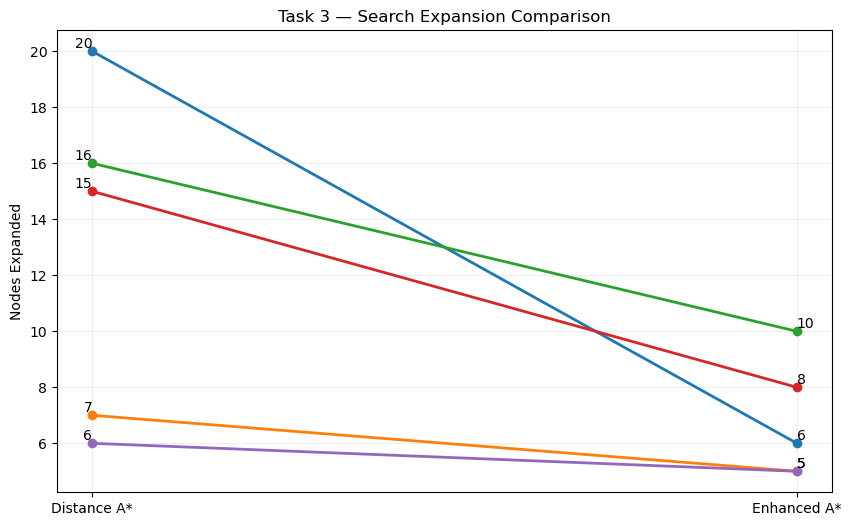

In [15]:
task3_expansion_df = pd.DataFrame({
    "Test": [f"{s} → {g}" for s, g in test_cases],
    "Distance A*": [r["Nodes Expanded"] for r in distance_results],
    "Enhanced A*": [r["Nodes Expanded"] for r in task3_results]
})

plt.figure(figsize=(10, 6))

for _, row in task3_expansion_df.iterrows():
    x = [0, 1]
    y = [row["Distance A*"], row["Enhanced A*"]]
    plt.plot(x, y, marker="o", linewidth=2)
    plt.text(0, y[0], str(y[0]), ha="right", va="bottom")
    plt.text(1, y[1], str(y[1]), ha="left", va="bottom")

plt.xticks([0, 1], ["Distance A*", "Enhanced A*"])
plt.ylabel("Nodes Expanded")
plt.title("Task 3 — Search Expansion Comparison")
plt.grid(alpha=0.2)
plt.show()

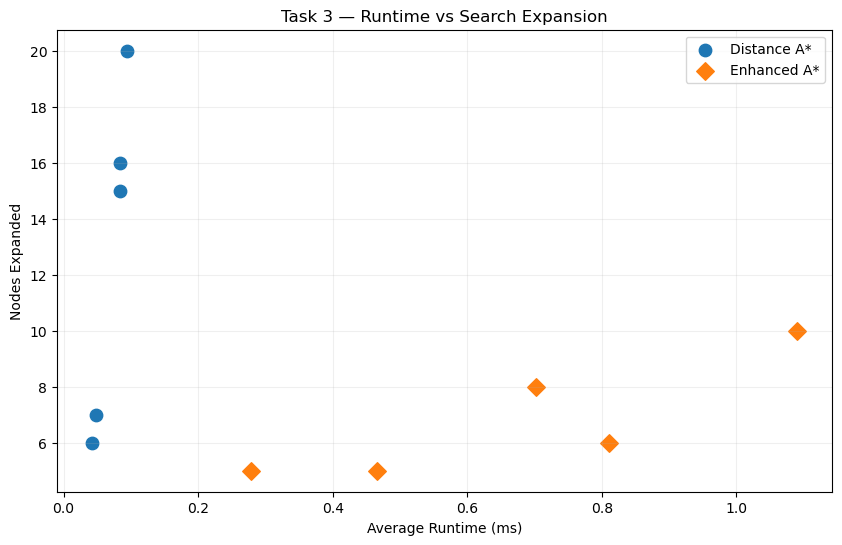

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    task3_runtime_df["Distance A* (ms)"],
    task3_expansion_df["Distance A*"],
    s=80,
    label="Distance A*"
)

plt.scatter(
    task3_runtime_df["Enhanced A* (ms)"],
    task3_expansion_df["Enhanced A*"],
    s=80,
    marker="D",
    label="Enhanced A*"
)

plt.xlabel("Average Runtime (ms)")
plt.ylabel("Nodes Expanded")
plt.title("Task 3 — Runtime vs Search Expansion")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 

### Task 3 -> Comparison of A* with Enhanced A*

In [17]:
task2_vs_task3 = []

for i, (start, goal) in enumerate(test_cases, start=1):
    p1, c1, e1 = a_star_distance(graph, start, goal)
    p2, c2, e2 = a_star_effort(graph, effort_graph, start, goal)

    task2_vs_task3.append({
        "Test": i,
        "Start": start,
        "Goal": goal,
        "Distance A* Path": " → ".join(p1),
        "Distance (m)": round(c1, 2),
        "Distance A* Expanded": e1,
        "Enhanced A* Path": " → ".join(p2),
        "Effort (EU)": round(c2, 2),
        "Enhanced A* Expanded": e2
    })

task2_vs_task3_df = pd.DataFrame(task2_vs_task3)
task2_vs_task3_df

,Test,Start,Goal,Distance A* Path,Distance (m),Distance A* Expanded,Enhanced A* Path,Effort (EU),Enhanced A* Expanded
0,1,N20,N13,N20 → N8 → N9 → N3 → N12 → N13,611.16,20,N20 → N8 → N9 → N3 → N12 → N13,1346.60,6
1,2,N1,N8,N1 → N18 → N7 → N21 → N8,202.07,7,N1 → N18 → N7 → N21 → N8,318.20,5
2,3,N15,N6,N15 → N11 → N18 → N7 → N21 → N19 → N6,545.89,16,N15 → N11 → N1 → N18 → N7 → N16 → N5 → N2 → N1...,1211.57,10
3,4,N17,N20,N17 → N4 → N5 → N16 → N7 → N21 → N8 → N20,394.76,15,N17 → N4 → N5 → N16 → N7 → N21 → N8 → N20,657.65,8
4,5,N4,N21,N4 → N5 → N16 → N7 → N21,195.58,6,N4 → N5 → N16 → N7 → N21,262.13,5


## 

## Task 4 -> Alternative Algorithm: Dijkstra algorithm

#### Dijkstra's algorithm is implemented using the same graph and environmental effort costs as Enhanced A*

#### Dijkstra does not use the heuristic; it provides the minimum-effort reference result against which the new Enhanced A* heuristic is evaluated.

In [18]:
def dijkstra(graph, effort_graph, start, goal):
    open_set = [(0, start)]
    came_from = {}
    g_score = {node: float("inf") for node in graph}
    g_score[start] = 0
    nodes_expanded = 0

    while open_set:
        current_cost, current = heapq.heappop(open_set)

        if current_cost > g_score[current]:
            continue

        nodes_expanded += 1

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path, g_score[goal], nodes_expanded

        for neighbour in graph[current]:
            edge_cost = effort_graph[current][neighbour]
            tentative_g = g_score[current] + edge_cost

            if tentative_g < g_score[neighbour]:
                came_from[neighbour] = current
                g_score[neighbour] = tentative_g
                heapq.heappush(open_set, (tentative_g, neighbour))

    return None, float("inf"), nodes_expanded

In [19]:
dijkstra_results = []

for start, goal in test_cases:
    path, cost, expanded = dijkstra(
        graph, effort_graph, start, goal
    )

    dijkstra_results.append({
        "Start": start,
        "Goal": goal,
        "Path": " → ".join(path),
        "Effort (EU)": round(cost, 2),
        "Nodes Expanded": expanded
    })

dijkstra_results_df = pd.DataFrame(dijkstra_results)
dijkstra_results_df

,Start,Goal,Path,Effort (EU),Nodes Expanded
0,N20,N13,N20 → N8 → N9 → N3 → N12 → N13,1346.60,21
1,N1,N8,N1 → N18 → N7 → N21 → N8,318.20,9
2,N15,N6,N15 → N11 → N1 → N18 → N7 → N16 → N5 → N2 → N1...,1211.57,20
3,N17,N20,N17 → N4 → N5 → N16 → N7 → N21 → N8 → N20,657.65,16
4,N4,N21,N4 → N5 → N16 → N7 → N21,262.13,8


### Task 4 -> Complexity and Runtime

In [20]:
task4_runtime = []
repetitions = 1000

for start, goal in test_cases:
    t0 = time.perf_counter()
    for _ in range(repetitions):
        reference_path_cache.clear()
        a_star_effort(graph, effort_graph, start, goal)
    t1 = time.perf_counter()
    effort_time = (t1 - t0) / repetitions * 1000

    t0 = time.perf_counter()
    for _ in range(repetitions):
        dijkstra(graph, effort_graph, start, goal)
    t1 = time.perf_counter()
    dijkstra_time = (t1 - t0) / repetitions * 1000

    task4_runtime.append({
        "Test": f"{start} → {goal}",
        "Enhanced A* (ms)": effort_time,
        "Dijkstra (ms)": dijkstra_time
    })

task4_runtime_df = pd.DataFrame(task4_runtime)
task4_runtime_df

,Test,Enhanced A* (ms),Dijkstra (ms)
0,N20 → N13,0.252944,0.014100
1,N1 → N8,0.144309,0.007844
2,N15 → N6,0.332543,0.013639
3,N17 → N20,0.192776,0.010550
4,N4 → N21,0.078344,0.005848


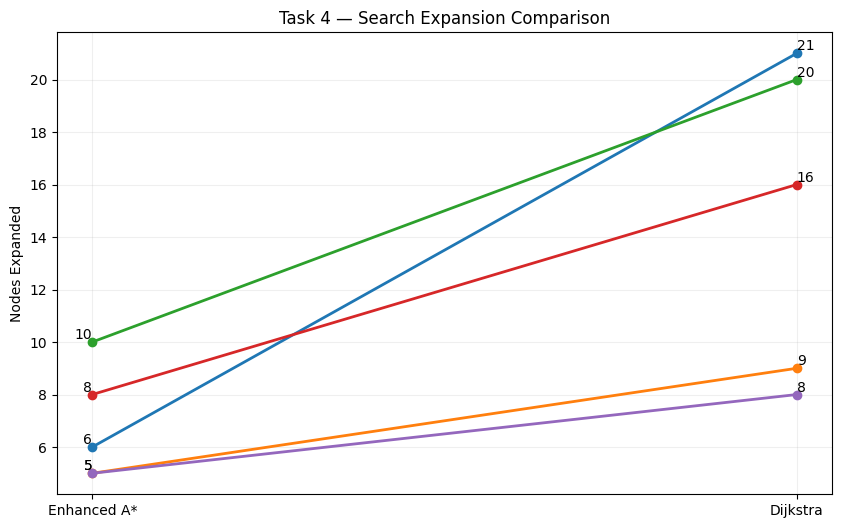

In [21]:
task4_expansion_df = pd.DataFrame({
    "Test": [f"{s} → {g}" for s, g in test_cases],
    "Enhanced A*": [r["Nodes Expanded"] for r in task3_results],
    "Dijkstra": [r["Nodes Expanded"] for r in dijkstra_results]
})

plt.figure(figsize=(10, 6))

for _, row in task4_expansion_df.iterrows():
    x = [0, 1]
    y = [row["Enhanced A*"], row["Dijkstra"]]
    plt.plot(x, y, marker="o", linewidth=2)
    plt.text(0, y[0], str(y[0]), ha="right", va="bottom")
    plt.text(1, y[1], str(y[1]), ha="left", va="bottom")

plt.xticks([0, 1], ["Enhanced A*", "Dijkstra"])
plt.ylabel("Nodes Expanded")
plt.title("Task 4 — Search Expansion Comparison")
plt.grid(alpha=0.2)
plt.show()

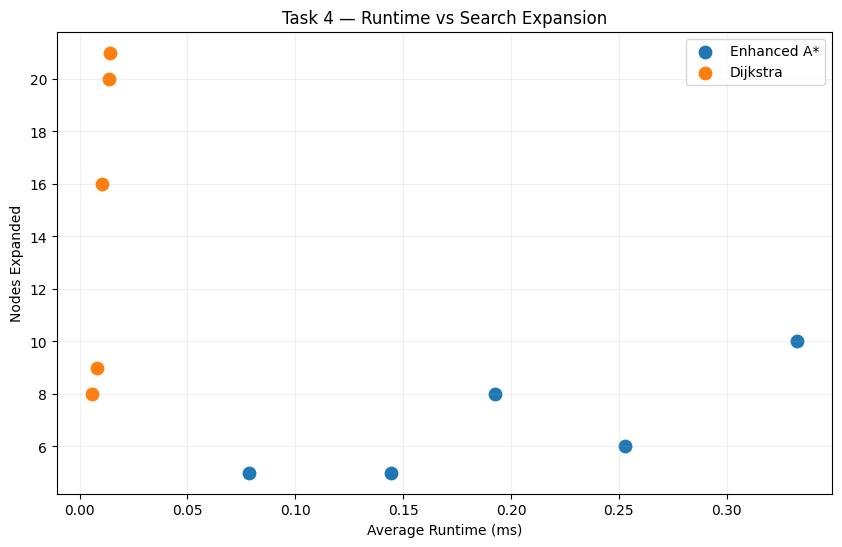

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    task4_runtime_df["Enhanced A* (ms)"],
    task4_expansion_df["Enhanced A*"],
    s=80,
    label="Enhanced A*"
)

plt.scatter(
    task4_runtime_df["Dijkstra (ms)"],
    task4_expansion_df["Dijkstra"],
    s=80,
    label="Dijkstra"
)

plt.xlabel("Average Runtime (ms)")
plt.ylabel("Nodes Expanded")
plt.title("Task 4 — Runtime vs Search Expansion")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [23]:
task4_comparison_df = pd.DataFrame({
    "Test": [f"{s} → {g}" for s, g in test_cases],
    "Enhanced A* Effort (EU)": [r["Effort (EU)"] for r in task3_results],
    "Enhanced A* Expanded": [r["Nodes Expanded"] for r in task3_results],
    "Dijkstra Effort (EU)": [r["Effort (EU)"] for r in dijkstra_results],
    "Dijkstra Expanded": [r["Nodes Expanded"] for r in dijkstra_results]
})

task4_comparison_df

,Test,Enhanced A* Effort (EU),Enhanced A* Expanded,Dijkstra Effort (EU),Dijkstra Expanded
0,N20 → N13,1346.60,6,1346.60,21
1,N1 → N8,318.20,5,318.20,9
2,N15 → N6,1211.57,10,1211.57,20
3,N17 → N20,657.65,8,657.65,16
4,N4 → N21,262.13,5,262.13,8


##

## Task 5 -> GUI

#### The GUI allows the user to select a start node, goal node, and algorithm. It animates node exploration and traces the final route.

# RUN THE BELOW GIVEN CELL IN ORDER TO GET THE GUI WINDOW

In [20]:
import tkinter as tk
from tkinter import ttk

BG = "#26332F"
PANEL = "#30413B"
CREAM = "#F4F0E6"
ROAD = "#C9C7BC"
TEXT = "#F7F4EA"
MUTED = "#B8C2BA"
SAGE = "#7FA68A"
ACTIVE = "#D9A441"
START = "#6FA8A1"
GOAL = "#C97865"
ROUTE = "#416B5F"

landmarks = {
    "N1": "Aachen Cathedral",
    "N2": "Aachen Town Hall",
    "N3": "Elisenbrunnen",
    "N4": "Cathedral Treasury",
    "N5": "Katschhof",
    "N6": "Marktplatz",
    "N7": "Centre Charlemagne",
    "N8": "Couven-Museum",
    "N9": "Puppenbrunnen",
    "N10": "Karlsbrunnen",
    "N11": "Grashaus",
    "N12": "Elisenpark",
    "N13": "Theater Aachen",
    "N14": "Kreislauf des Geldes",
    "N15": "Elisabethhalle",
    "N16": "Katschhof Vitrine",
    "N17": "Löwenbrunnen",
    "N18": "St. Foillan Church",
    "N19": "Haus Löwenstein",
    "N20": "Bahkauv Fountain",
    "N21": "Hühnermarkt"
}

root = tk.Tk()
root.title("Aachen | Wheelchair Route Planner")
root.geometry("1200x720")
root.configure(bg=BG)

left = tk.Frame(root, bg=PANEL, width=310)
left.pack(side="left", fill="y")
left.pack_propagate(False)

tk.Label(left, text="AACHEN", bg=PANEL, fg=SAGE,
         font=("Arial", 25, "bold")).pack(anchor="w", padx=25, pady=(25, 0))
tk.Label(left, text="WHEELCHAIR ROUTE PLANNER", bg=PANEL, fg=TEXT,
         font=("Arial", 10, "bold")).pack(anchor="w", padx=27, pady=(0, 25))

def make_label(text):
    tk.Label(left, text=text, bg=PANEL, fg=MUTED,
             font=("Arial", 9, "bold")).pack(anchor="w", padx=27, pady=(8, 4))

make_label("START NODE")
start_box = ttk.Combobox(left, values=list(graph.keys()), state="readonly", width=23)
start_box.set("N20")
start_box.pack(padx=25, fill="x")

make_label("GOAL NODE")
goal_box = ttk.Combobox(left, values=list(graph.keys()), state="readonly", width=23)
goal_box.set("N13")
goal_box.pack(padx=25, fill="x")

make_label("ALGORITHM")
algorithm_box = ttk.Combobox(
    left,
    values=["A*", "Enhanced A*", "Dijkstra"],
    state="readonly",
    width=23
)
algorithm_box.set("Enhanced A*")
algorithm_box.pack(padx=25, fill="x")

status = tk.Label(left, text="Ready to search", bg=PANEL, fg=ACTIVE,
                  font=("Arial", 10, "bold"), justify="left", wraplength=250)
status.pack(anchor="w", padx=27, pady=(25, 10))

cost_label = tk.Label(left, text="Cost: —", bg=PANEL, fg=TEXT,
                      font=("Arial", 11, "bold"))
cost_label.pack(anchor="w", padx=27)

expanded_label = tk.Label(left, text="Nodes explored: —", bg=PANEL, fg=TEXT,
                          font=("Arial", 10))
expanded_label.pack(anchor="w", padx=27, pady=5)

route_label = tk.Label(left, text="Route will appear here", bg="#25312D",
                       fg=TEXT, font=("Arial", 9), justify="left",
                       wraplength=250, padx=12, pady=12)
route_label.pack(fill="x", padx=20, pady=15)

right = tk.Frame(root, bg=CREAM)
right.pack(side="right", fill="both", expand=True)

canvas = tk.Canvas(right, bg=CREAM, highlightthickness=0)
canvas.pack(fill="both", expand=True, padx=15, pady=15)

def position(node):
    lat, lon = coordinates[node]
    lats = [v[0] for v in coordinates.values()]
    lons = [v[1] for v in coordinates.values()]

    lat_min, lat_max = min(lats), max(lats)
    lon_min, lon_max = min(lons), max(lons)

    margin = 80
    width, height = 850, 620

    scale_x = (width - 2 * margin) / (lon_max - lon_min)
    scale_y = (height - 2 * margin) / (lat_max - lat_min)
    scale = min(scale_x, scale_y)

    map_width = (lon_max - lon_min) * scale
    map_height = (lat_max - lat_min) * scale

    x0 = (width - map_width) / 2
    y0 = (height - map_height) / 2

    x = x0 + (lon - lon_min) * scale
    y = height - (y0 + (lat - lat_min) * scale)

    return x, y

def draw_map():
    canvas.delete("all")
    canvas.create_text(35, 30, text="AACHEN PATH NETWORK",
                       anchor="w", fill=BG, font=("Arial", 15, "bold"))
    canvas.create_text(35, 52, text="Visualisation",
                       anchor="w", fill="#6B756F", font=("Arial", 9))

    for node in graph:
        for neighbour in graph[node]:
            if node < neighbour:
                x1, y1 = position(node)
                x2, y2 = position(neighbour)
                canvas.create_line(x1, y1, x2, y2, fill=ROAD, width=3)

    for node in graph:
        x, y = position(node)
        canvas.create_oval(x-7, y-7, x+7, y+7,
                           fill=BG, outline=CREAM, width=2)
        canvas.create_text(x+13, y, text=node, anchor="w",
                           fill=BG, font=("Arial", 8, "bold"))

    legend = [(START, "Start"), (GOAL, "Goal"),
              (SAGE, "Explored"), (ROUTE, "Final route")]
    x = 35
    for colour, label in legend:
        canvas.create_oval(x, 665, x+12, 677, fill=colour, outline="")
        canvas.create_text(x+19, 671, text=label, anchor="w",
                           fill=BG, font=("Arial", 9))
        x += 105

draw_map()

def reconstruct(came_from, start, goal):
    path = [goal]
    current = goal
    while current != start:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

def run_distance_visual(start, goal):
    open_set = [(haversine_distance(start, goal), start)]
    came_from = {}
    g = {n: float("inf") for n in graph}
    g[start] = 0
    explored, snapshots = [], []

    while open_set:
        _, current = heapq.heappop(open_set)
        if current in explored:
            continue

        explored.append(current)
        snapshots.append((current, g[current], len(open_set)))

        if current == goal:
            break

        for neighbour in graph[current]:
            new_g = g[current] + graph[current][neighbour]
            if new_g < g[neighbour]:
                g[neighbour] = new_g
                came_from[neighbour] = current
                f = new_g + haversine_distance(neighbour, goal)
                heapq.heappush(open_set, (f, neighbour))

    if goal not in came_from and start != goal:
        return None

    return explored, snapshots, reconstruct(came_from, start, goal), g[goal]

def run_effort_visual(start, goal):
    open_set = [(effort_heuristic(start, goal, graph, effort_graph), start)]
    came_from = {}
    g = {n: float("inf") for n in graph}
    g[start] = 0
    explored, snapshots = [], []

    while open_set:
        _, current = heapq.heappop(open_set)
        if current in explored:
            continue

        explored.append(current)
        snapshots.append((current, g[current], len(open_set)))

        if current == goal:
            break

        for neighbour in graph[current]:
            edge = effort_graph[current][neighbour]
            new_g = g[current] + edge

            if new_g < g[neighbour]:
                g[neighbour] = new_g
                came_from[neighbour] = current
                f = new_g + effort_heuristic(neighbour, goal, graph, effort_graph)
                heapq.heappush(open_set, (f, neighbour))

    if goal not in came_from and start != goal:
        return None

    return explored, snapshots, reconstruct(came_from, start, goal), g[goal]

def run_dijkstra_visual(start, goal):
    open_set = [(0, start)]
    came_from = {}
    g = {n: float("inf") for n in graph}
    g[start] = 0
    explored, snapshots = [], []

    while open_set:
        cost, current = heapq.heappop(open_set)

        if current in explored:
            continue

        explored.append(current)
        snapshots.append((current, g[current], len(open_set)))

        if current == goal:
            break

        for neighbour in graph[current]:
            edge = effort_graph[current][neighbour]
            new_g = g[current] + edge

            if new_g < g[neighbour]:
                g[neighbour] = new_g
                came_from[neighbour] = current
                heapq.heappush(open_set, (new_g, neighbour))

    if goal not in came_from and start != goal:
        return None

    return explored, snapshots, reconstruct(came_from, start, goal), g[goal]

def reset_map():
    draw_map()

def start_search():
    global search_data, animation_index

    start = start_box.get()
    goal = goal_box.get()
    algorithm = algorithm_box.get()

    if start == goal:
        status.config(text="Start and goal cannot be the same.")
        return

    reset_map()

    if algorithm == "A*":
        search_data = run_distance_visual(start, goal)
    elif algorithm == "Enhanced A*":
        search_data = run_effort_visual(start, goal)
    else:
        search_data = run_dijkstra_visual(start, goal)

    if search_data is None:
        status.config(text="No route found.")
        return

    animation_index = 0
    route_label.config(text="Searching...")
    animate_search()

def animate_search():
    global animation_index

    explored, snapshots, path, final_cost = search_data

    if animation_index >= len(snapshots):
        trace_path(path, 0, 0)
        return

    current, cost, open_count = snapshots[animation_index]
    x, y = position(current)

    canvas.create_oval(x-11, y-11, x+11, y+11,
                       fill=ACTIVE, outline=CREAM, width=3, tags="animation")

    if current == start_box.get():
        canvas.create_oval(x-8, y-8, x+8, y+8,
                           fill=START, outline=CREAM, width=2, tags="animation")
    elif current == goal_box.get():
        canvas.create_oval(x-8, y-8, x+8, y+8,
                           fill=GOAL, outline=CREAM, width=2, tags="animation")
    else:
        canvas.create_oval(x-7, y-7, x+7, y+7,
                           fill=SAGE, outline=CREAM, width=2, tags="animation")

    unit = "m" if algorithm_box.get() == "A*" else "EU"

    status.config(
        text=f"Exploring {current}\n"
             f"Accumulated cost: {cost:.2f} {unit}\n"
             f"OPEN nodes: {open_count}"
    )
    expanded_label.config(text=f"Nodes explored: {animation_index + 1}")

    animation_index += 1
    root.after(600, animate_search)

def trace_path(path, index, total_cost):
    algorithm = algorithm_box.get()

    if index >= len(path) - 1:
        unit = "m" if algorithm == "A*" else "EU"

        status.config(text="FINAL ROUTE FOUND")
        cost_label.config(text=f"Final cost: {total_cost:.2f} {unit}")

        route_label.config(
            text=" → ".join(path) + "\n\nLandmarks:\n" +
                 "\n".join(f"• {landmarks[n]}" for n in path)
        )
        return

    current, next_node = path[index], path[index + 1]
    x1, y1 = position(current)
    x2, y2 = position(next_node)

    if algorithm == "A*":
        edge_cost = graph[current][next_node]
        unit = "m"
    else:
        edge_cost = effort_graph[current][next_node]
        unit = "EU"

    total_cost += edge_cost

    canvas.create_line(x1, y1, x2, y2, fill=ROUTE,
                       width=8, capstyle="round", tags="route")
    canvas.create_oval(x2-10, y2-10, x2+10, y2+10,
                       fill=ROUTE, outline=CREAM, width=3, tags="route")

    status.config(text=f"Tracing final route\n{current} → {next_node}")
    cost_label.config(text=f"Route cost: {total_cost:.2f} {unit}")

    root.after(800, lambda: trace_path(path, index + 1, total_cost))

tk.Button(
    left, text="FIND ROUTE", command=start_search,
    bg=SAGE, fg=BG, activebackground="#9FBEA8",
    relief="flat", font=("Arial", 11, "bold"),
    padx=15, pady=11, cursor="hand2"
).pack(padx=25, pady=8, fill="x")

root.mainloop()